# Single qubit signal detection with lorenzian noise using FF

In [1]:
import gpulse
import matplotlib.pyplot as plt 
from pprint import pprint

### Generate Signal PSD

In [2]:
# Signal power
signal_power = 0.0012
# Length of the initial noise filter
length = 128*2
# Cutoff frequency for the initial filter
cutoff = 0.01
# Target interpulse spacing
target_tau = 5
# Target frequency
w0 =  1 / (2 * target_tau)


In [3]:
signal_generator  = gpulse.Noise(signal_power, length, cutoff, w0)

ws = signal_generator.w
hs = signal_generator.h


# Compute power spectral density
signal_psd = abs(hs)**2

## Generate noise PSD

In [4]:
# parameter decides width of noise
gamma =  0.5

# center of the noise lorenzian psd
center = 0

# Signal to noise ratio
snr = 0.2

# Generate a lorenzian noise PSD
noise_psd = gpulse.noise_models.lorenzian(ws, center, gamma, signal_power / snr )


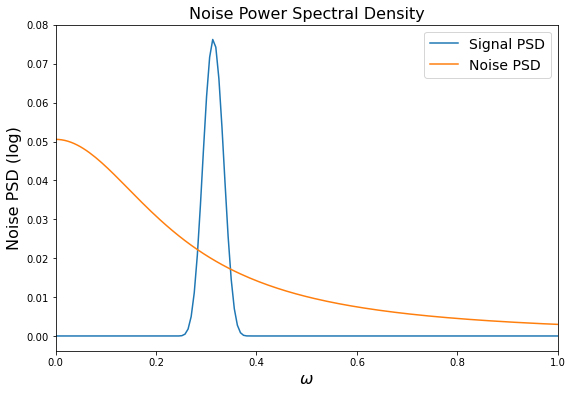

In [5]:
plt.figure(figsize=(9,6))
plt.plot(ws, signal_psd, label='Signal PSD')
plt.plot(ws, noise_psd, label='Noise PSD')
plt.xlabel(r'$\omega$', size=16)
plt.ylabel('Noise PSD (log)', size =16)
plt.title("Noise Power Spectral Density", size=16);
plt.legend(fontsize=14);
plt.xlim(0, 1);

## Create a new optimisation job

Jobs are defined by a dictionary holding algorithm inputs. This can be generated using the helper function `gpulse.create_job()`.  If no argument is given, it creates a default job.

In [6]:
job = gpulse.create_job()

In [7]:
pprint(job)

{'CPMG_CYCLES': 5,
 'CXPB': 0.3,
 'GPB': 0.5,
 'MAX_SHOTS': 1000,
 'MUTPB': 0.5,
 'NGEN': 50,
 'POP_SIZE': 100,
 'TAU_MAX': 10,
 'TAU_MIN': 1,
 'X_ROT_MAX': 10,
 'X_ROT_MIN': 1,
 'cfn_args': [],
 'cfn_kwargs': [],
 'cost_function': <function cost_sig_noise at 0x7fafecd490d0>,
 'fixed_cycles': False,
 'fixed_rotation': False,
 'fixed_shots': False,
 'fixed_timing': False,
 'optimise': 'max'}


Full details about the parameters can be found by running `help(gpulse.create_job)`.

We can change parameters as usual with a dictionary.

In [8]:
job['MUTPB'] = 0.7
print(job['MUTPB'])

0.7


We can also do this in one go when creating the job by providing the values we want to change from the default.

In [9]:
my_job = {'MUTPB' : 0.3,
          'CXPB' : 0.6,
          'CPMG_CYCLES' : 7,
         }
job = gpulse.create_job(my_job)
pprint(job)

{'CPMG_CYCLES': 7,
 'CXPB': 0.6,
 'GPB': 0.5,
 'MAX_SHOTS': 1000,
 'MUTPB': 0.3,
 'NGEN': 50,
 'POP_SIZE': 100,
 'TAU_MAX': 10,
 'TAU_MIN': 1,
 'X_ROT_MAX': 10,
 'X_ROT_MIN': 1,
 'cfn_args': [],
 'cfn_kwargs': [],
 'cost_function': <function cost_sig_noise at 0x7fafecd490d0>,
 'fixed_cycles': False,
 'fixed_rotation': False,
 'fixed_shots': False,
 'fixed_timing': False,
 'optimise': 'max'}


The default cost function used is `gpulse.costfn.cost_sig_noise`. This function compuates the difference in decay probabilities of the qubit with just noise and with signal + noise using the filter function of the pulse.

$\large cost = \frac{e^{-\chi_{noise}}(1 - e^{-\chi_{sig}})}{2} $



The function needs to be provided with noise and signal PSDs as keyword arguments. We can do this using a dictionary.

In [10]:
kwargs = {'SIGNAL_PSD' : signal_psd,
          'NOISE_PSD' : noise_psd
         }
job['cfn_kwargs'] = kwargs

Any other cost function can be used as long as the first positional argument accepts a pulse of the form \[$(\tau_1, \theta_1)$, $(\tau_2, \theta_2)$ ... $(\tau_n, \theta_n)$ \], where $\tau$ are the interpulse spacing of the CPMG ansatz and $\theta$ are the $X$ rotation angles. The pulse generated will be


<p align="center">
-$\tau$-$R_x(\theta_1)$-2$\tau$-$R_x(\theta_1)$-$\tau$-$R_x(\theta_2)$-$\tau$-...
</p>

##  Run the optimiser

Jobs are handled by the `gpulse.optmiser.Optimiser` class. An instance is initialised with a job input

In [11]:
opt = gpulse.optimiser.Optimiser(job)

The jobs is run using the `run()` method.

In [12]:
result = opt.run()

Job 1
------
Generation 		 Best Individual
		      τ1 τ2..τn | θ1 θ2..θn
------------------------------------------------------------
5 		 5 2 2 1 5 2 | 2π/3 2π/3 2π/7 2π/5 2π/2 2π/5 
10 		 5 2 2 1 5 2 | 2π/3 2π/3 2π/7 2π/5 2π/2 2π/5 
15 		 5 2 2 1 5 2 | 2π/3 2π/3 2π/7 2π/5 2π/2 2π/5 
20 		 5 6 2 1 3 2 3 | 2π/2 2π/2 2π/7 2π/5 2π/3 2π/5 2π/3 
25 		 5 6 2 1 3 2 3 | 2π/2 2π/2 2π/7 2π/5 2π/3 2π/5 2π/3 
30 		 5 6 2 1 3 2 3 | 2π/2 2π/2 2π/7 2π/5 2π/3 2π/5 2π/3 
35 		 5 6 2 1 3 2 3 | 2π/2 2π/2 2π/7 2π/5 2π/3 2π/5 2π/3 
40 		 5 6 2 1 3 2 3 | 2π/2 2π/2 2π/7 2π/5 2π/3 2π/5 2π/3 
45 		 5 6 2 1 3 2 3 | 2π/2 2π/2 2π/7 2π/5 2π/3 2π/5 2π/3 




Individuals are printed out as $\tau_1 \tau_2 \dots \tau_n | \theta_1 \theta_2 \dots \theta_n $ 

The outcome of the job returns a deap logbook with the fitness statistics and the best individual.

In [13]:
log, best_ind = result[0]

In [14]:
print(best_ind)

[[5, 2], [6, 2], [2, 7], [1, 5], [3, 3], [2, 5], [3, 3]]


Internally the pulse individual is stored as \[ $[\tau_1, \frac{2\pi}{\theta_1} ]$, $[\tau_2, \frac{2\pi}{\theta_2} ]$, ... ,$[\tau_n, \frac{2\pi}{\theta_n} ]$\]

In [15]:
print(log)

gen	max      	avg       	min        	std      
0  	0.0552569	0.00755244	0.000289842	0.0079707
1  	0.0725111	0.0152382 	1.14218e-05	0.0138222
2  	0.0847419	0.0259899 	0.002368   	0.0197135
3  	0.0847419	0.0408667 	0.00133267 	0.0246187
4  	0.0847419	0.054035  	0.0018501  	0.0271831
5  	0.12662  	0.0650002 	0.00248056 	0.0297218
6  	0.12662  	0.0629829 	0.00155708 	0.0344437
7  	0.12662  	0.062494  	0.00247908 	0.0384516
8  	0.12662  	0.0731184 	0.00152422 	0.0392379
9  	0.12662  	0.0751368 	0.00248483 	0.0484604
10 	0.12662  	0.0909351 	0.000706237	0.0491262
11 	0.12662  	0.0970726 	0.0023234  	0.0468767
12 	0.12662  	0.0831308 	0.0015797  	0.052851 
13 	0.12662  	0.0934479 	0.00103677 	0.0491311
14 	0.12662  	0.100383  	0.00369899 	0.0460226
15 	0.12662  	0.101554  	0.0029491  	0.0448198
16 	0.12662  	0.0825671 	0.00124463 	0.0529477
17 	0.12662  	0.0888618 	0.0028926  	0.0517511
18 	0.128727 	0.0880226 	0.0030586  	0.0532699
19 	0.128727 	0.0972299 	0.00421815 	0.0481276
20 	0.155171 

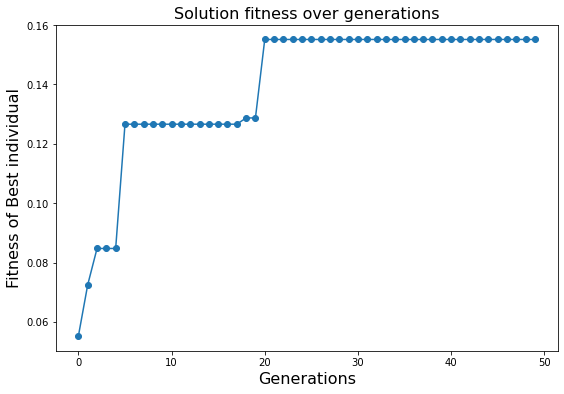

In [16]:
plt.figure(figsize=(9,6))
fitness_max = [log[i]['max'] for i in range(len(log)) ] 
gen = [log[i]['gen'] for i in range(len(log)) ]
plt.plot(gen, fitness_max,'-o')
plt.xlabel('Generations', size=16)
plt.ylabel('Fitness of Best individual', size=16);
plt.title('Solution fitness over generations', size=16);

## Running multiple jobs

The optimiser can be initialised with multiple jobs as well using `gpulse.Optimiser(job_1, job_2,..)`

In [17]:
kwargs = {'SIGNAL_PSD' : signal_psd,
          'NOISE_PSD' : noise_psd
         }

my_job_1 = {'MUTPB' : 0.3,
         'CXPB' : 0.6,
         'cfn_kwargs' : kwargs
        }

my_job_2 = {'CPMG_CYCLES' : 7,
         'CXPB' : 0.2,
         'cfn_kwargs' : kwargs
        }

jobs = [gpulse.create_job(j) for j in [my_job_1, my_job_2]]


In [18]:
opt = gpulse.Optimiser(*jobs)

In [19]:
result = opt.run()

Job 1
------
Generation 		 Best Individual
		      τ1 τ2..τn | θ1 θ2..θn
------------------------------------------------------------
5 		 3 5 3 4 | 2π/5 2π/2 2π/4 2π/2 
10 		 3 5 3 4 | 2π/5 2π/2 2π/4 2π/2 
15 		 3 5 3 4 | 2π/5 2π/2 2π/4 2π/2 
20 		 3 5 5 4 | 2π/5 2π/2 2π/2 2π/2 
25 		 3 5 5 4 | 2π/5 2π/2 2π/2 2π/2 
30 		 3 5 5 4 | 2π/4 2π/2 2π/2 2π/2 
35 		 3 5 5 4 | 2π/4 2π/2 2π/2 2π/2 
40 		 3 5 5 4 | 2π/4 2π/2 2π/2 2π/2 
45 		 3 5 5 4 | 2π/4 2π/2 2π/2 2π/2 


Job 2
------
Generation 		 Best Individual
		      τ1 τ2..τn | θ1 θ2..θn
------------------------------------------------------------
5 		 6 4 4 6 2 3 | 2π/3 2π/2 2π/2 2π/2 2π/6 2π/4 
10 		 6 5 4 6 2 | 2π/3 2π/2 2π/2 2π/2 2π/6 
15 		 1 6 2 6 | 2π/1 2π/2 2π/4 2π/2 
20 		 1 5 4 6 | 2π/1 2π/2 2π/2 2π/2 
25 		 5 5 4 6 | 2π/2 2π/2 2π/2 2π/2 
30 		 5 5 4 6 | 2π/2 2π/2 2π/2 2π/2 
35 		 5 5 4 6 | 2π/2 2π/2 2π/2 2π/2 
40 		 5 5 4 6 | 2π/2 2π/2 2π/2 2π/2 
45 		 5 5 4 6 | 2π/2 2π/2 2π/2 2π/2 




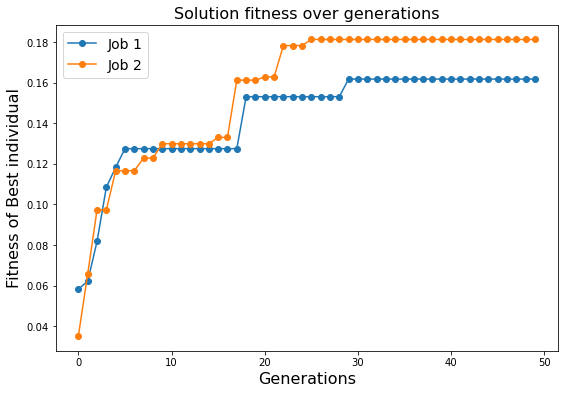

In [20]:
plt.figure(figsize=(9,6))
for idx,r in enumerate(result):
    log, best_ind = r
    fitness_max = [log[i]['max'] for i in range(len(log)) ] 
    gen = [log[i]['gen'] for i in range(len(log)) ]
    plt.plot(gen, fitness_max,'-o', label='Job ' + str(idx + 1))
plt.xlabel('Generations', size=16)
plt.ylabel('Fitness of Best individual', size=16);
plt.title('Solution fitness over generations', size=16);
plt.legend(fontsize=14);    
    